In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
import torch
import os

In [2]:
df1 = pd.read_csv('experiment_metrics_fully_parallel/default1.csv')
df2 = pd.read_csv('experiment_metrics_fully_parallel/default2.csv')
df3 = pd.read_csv('experiment_metrics_fully_parallel/default3.csv')

print(df1.columns)

Index(['equiv/t=0.99/pct_loss_from_equiv_error', 'equiv/t=0.4/mean_grad_norm',
       'equiv/t=0.99/grad_norm_ratio_equiv_over_mean',
       'equiv/t=0.99/total_mse', 'equiv/t=0.9/equiv_error',
       'validation_loss/auxiliary_loss_no_w_epoch', 'scaling/nparams',
       'train/loss_epoch', 'train/auxiliary_loss_step',
       'equiv/t=0.2/mean_grad_norm', 'equiv/t=0.4/mean_pred_error',
       'equiv/t=0.95/grad_norm_ratio_equiv_over_mean', 'train/trans_loss_step',
       'equiv/t=0.6/equiv_grad_norm', 'equiv/t=0/mean_grad_norm',
       'equiv/t=0.6/mean_pred_error', 'validation_loss/trans_loss_step',
       'equiv/t=0.4/pct_loss_from_equiv_error',
       'equiv/t=0.9/pct_loss_from_equiv_error', 'equiv/t=0.99/mean_pred_error',
       'equiv/t=0.95/pct_loss_from_equiv_error', 'train/dist_mat_loss_epoch',
       'validation_loss/distogram_loss_epoch', 'equiv/t=0.6/total_mse',
       'train/auxiliary_loss_no_w_epoch', 'train/dist_mat_loss_step',
       'equiv/t=0.8/equiv_error', 'equiv/t=0

In [3]:
mdf = pd.merge(df1, df2, on=['_step'], suffixes=('_1', '_2'))

df3 = df3.rename(columns={c: f'{c}_3' for c in df3.columns if c != '_step'})

mdf = pd.merge(mdf, df3, on=['_step'], suffixes=('', '_3'))

mdf.columns

Index(['equiv/t=0.99/pct_loss_from_equiv_error_1',
       'equiv/t=0.4/mean_grad_norm_1',
       'equiv/t=0.99/grad_norm_ratio_equiv_over_mean_1',
       'equiv/t=0.99/total_mse_1', 'equiv/t=0.9/equiv_error_1',
       'validation_loss/auxiliary_loss_no_w_epoch_1', 'scaling/nparams_1',
       'train/loss_epoch_1', 'train/auxiliary_loss_step_1',
       'equiv/t=0.2/mean_grad_norm_1',
       ...
       'equiv/t=0.9/total_mse_3', 'validation_loss/trans_loss_epoch_3',
       'equiv/t=0.6/equiv_error_3',
       'equiv/t=0.2/grad_norm_ratio_equiv_over_mean_3',
       'validation_loss/auxiliary_loss_no_w_epoch_3',
       'train/auxiliary_loss_no_w_step_3', 'equiv/t=0.6/mean_grad_norm_3',
       'equiv/t=0.99/pct_loss_from_equiv_error_3',
       'equiv/t=0.2/mean_pred_error_3', 'equiv/t=0.9/mean_grad_norm_3'],
      dtype='object', length=271)

In [11]:
cols = ['_step'] + [col for col in df1.columns if col.startswith('equiv/t=') and col.endswith('pct_loss_from_equiv_error')]
print(cols)

df1[cols].dropna().reset_index(drop=True).set_index('_step')

['_step', 'equiv/t=0.99/pct_loss_from_equiv_error', 'equiv/t=0.4/pct_loss_from_equiv_error', 'equiv/t=0.9/pct_loss_from_equiv_error', 'equiv/t=0.95/pct_loss_from_equiv_error', 'equiv/t=0/pct_loss_from_equiv_error', 'equiv/t=0.6/pct_loss_from_equiv_error', 'equiv/t=0.2/pct_loss_from_equiv_error', 'equiv/t=0.8/pct_loss_from_equiv_error']


,equiv/t=0.99/pct_loss_from_equiv_error,equiv/t=0.4/pct_loss_from_equiv_error,equiv/t=0.9/pct_loss_from_equiv_error,equiv/t=0.95/pct_loss_from_equiv_error,equiv/t=0/pct_loss_from_equiv_error,equiv/t=0.6/pct_loss_from_equiv_error,equiv/t=0.2/pct_loss_from_equiv_error,equiv/t=0.8/pct_loss_from_equiv_error
_step,,,,,,,,
113,0.106436,0.106420,0.110051,0.108772,0.101503,0.109629,0.105373,0.113418
227,0.083048,0.082495,0.083820,0.082784,0.079702,0.083705,0.080784,0.082842
341,0.062965,0.068058,0.066055,0.061759,0.062143,0.069561,0.065833,0.066980
455,0.049204,0.052704,0.049048,0.048548,0.048714,0.051647,0.051179,0.049718
569,0.036701,0.040688,0.036432,0.036884,0.036855,0.038705,0.038972,0.035944
...,...,...,...,...,...,...,...,...
628470,0.031280,0.015470,0.047992,0.045791,0.000298,0.020415,0.010429,0.034718
628584,0.032804,0.015887,0.049272,0.047790,0.000332,0.023615,0.005290,0.034052
628698,0.029487,0.017040,0.048808,0.047003,0.000333,0.026131,0.007091,0.035056


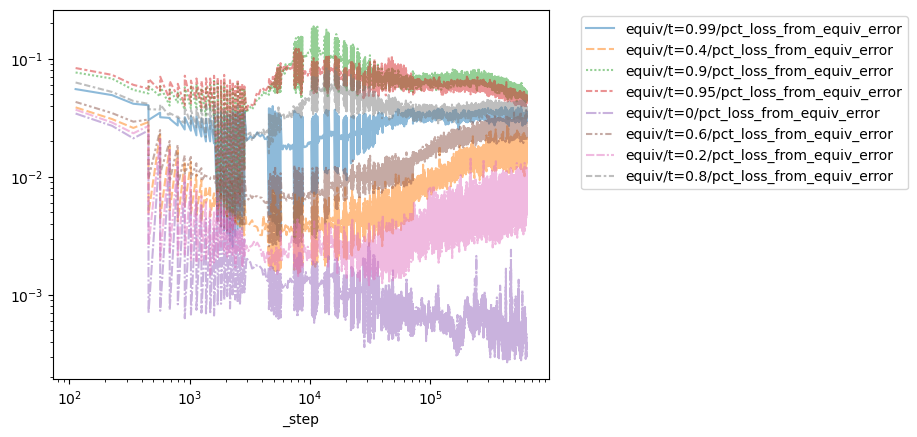

In [14]:
sns.lineplot(
    data = df1[cols].dropna().reset_index(drop=True).set_index('_step'),
    # hue = ''
    # color = '#00a0dc',
    errorbar = None,
    alpha=0.5,
)

plt.yscale('log')
plt.xscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

